In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)


Text(0.5, 1.0, 'Synthetic Classification Dataset')

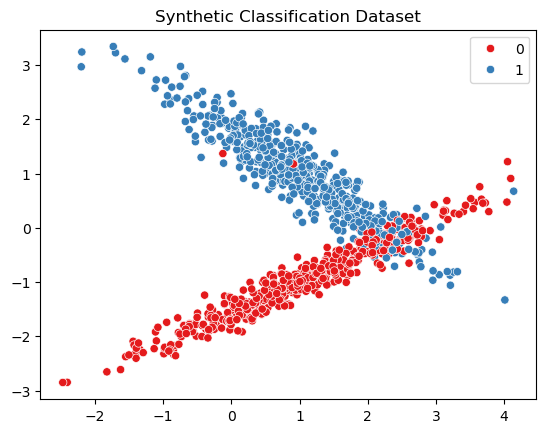

In [4]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1')
plt.title('Synthetic Classification Dataset')

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [9]:
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       124
           1       0.93      0.83      0.88       126

    accuracy                           0.88       250
   macro avg       0.89      0.88      0.88       250
weighted avg       0.89      0.88      0.88       250

[[116   8]
 [ 21 105]]


In [ ]:
## LINEAR SVM

In [15]:
from sklearn import svm
svm_model = svm.SVC(kernel='linear')

In [16]:
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       124
           1       0.99      0.83      0.91       126

    accuracy                           0.91       250
   macro avg       0.92      0.91      0.91       250
weighted avg       0.92      0.91      0.91       250

[[123   1]
 [ 21 105]]


In [18]:
from sklearn import svm
rbf_model = svm.SVC(kernel='rbf')

In [19]:
rbf_model.fit(X_train, y_train)
y_pred_rbf = rbf_model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       124
           1       0.99      0.84      0.91       126

    accuracy                           0.92       250
   macro avg       0.93      0.92      0.92       250
weighted avg       0.93      0.92      0.92       250

[[123   1]
 [ 20 106]]


In [23]:
from sklearn import svm
poly_model = svm.SVC(kernel='poly')

In [24]:
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

Text(0.5, 1.0, 'Training Data with Polynomial SVM Decision Boundary')

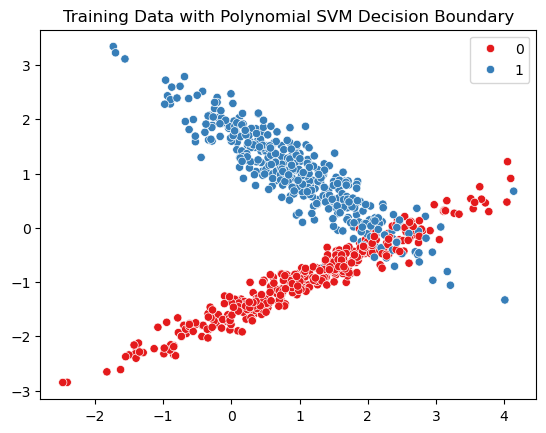

In [27]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette='Set1')
plt.title('Training Data with Polynomial SVM Decision Boundary')

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       124
           1       0.95      0.85      0.90       126

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

[[118   6]
 [ 19 107]]


In [26]:
from sklearn import svm
polyd_model = svm.SVC(kernel='poly',degree=3)

In [28]:
polyd_model.fit(X_train, y_train)
y_pred_polyd = polyd_model.predict(X_test)

Text(0.5, 1.0, 'Training Data with Polynomial degree 3 SVM Decision Boundary')

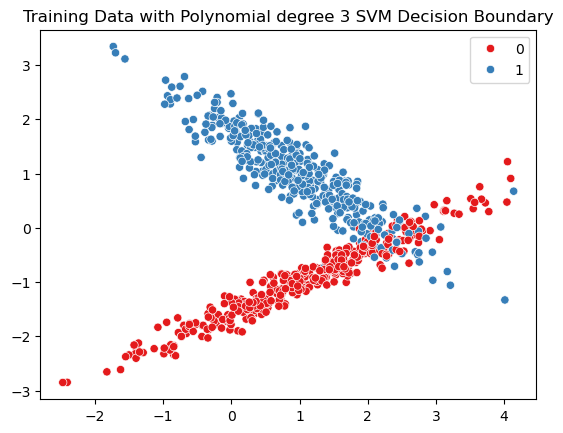

In [29]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette='Set1')
plt.title('Training Data with Polynomial degree 3 SVM Decision Boundary')

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_polyd))
print(confusion_matrix(y_test, y_pred_polyd))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       124
           1       0.95      0.85      0.90       126

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

[[118   6]
 [ 19 107]]


In [31]:
from sklearn import svm

sigmoid_model = svm.SVC(kernel='sigmoid')

In [32]:
sigmoid_model.fit(X_train, y_train)
y_pred_sigmoid = sigmoid_model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_sigmoid))
print(confusion_matrix(y_test, y_pred_sigmoid))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       124
           1       0.95      0.83      0.89       126

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

[[119   5]
 [ 21 105]]


In [ ]:
##Hyperparameter Tuning for SVM

In [40]:
params_grid = {
    'C': [0.1, 1, 10, 100,1000],
    'gamma': [1, 0.1, 0.01, 0.001,0.0001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(svm.SVC(), param_grid=params_grid, refit=True, cv=5,verbose=3)

In [43]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.953 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.940 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.947 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.967 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.907 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.933 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.860 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=1, kernel=sigmoid

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly', 'sigmoid']},
             verbose=3)

In [44]:
grid.best_estimator_

SVC(C=10, gamma=1)

In [45]:
grid.best_score_

np.float64(0.9480000000000001)

In [46]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [47]:
grid.best_index_

np.int64(30)